### Setup

In [25]:
import sys
print(sys.executable)

/common/software/install/migrated/pytorch/1.2_python3.7/bin/python


In [26]:
%cd /projects/standard/csci5527/shared/lossangels/CubiCasa5k

/projects/standard/csci5527/shared/lossangels/CubiCasa5k


In [32]:
import sys
!{sys.executable} -m pip install \
    scikit-image \
    opencv-python-headless \
    lmdb==0.98 \
    pandas \
    matplotlib \
    tensorboardX \
    tqdm \
    pandas \
    svgpathtools \
    shapely \
    --quiet

In [28]:
import torch
torch.cuda.is_available()

True

### Clone Repo

In [29]:
!sed -i 's/numpy==1.15.4/numpy==1.26.4/g' requirements.txt
!sed -i 's/mkl-fft==1.0.6/mkl-fft/g' requirements.txt
!sed -i 's/h5py==2.8.0/h5py==3.10.0/g' requirements.txt

In [30]:
%cd /projects/standard/csci5527/shared/lossangels/CubiCasa5k

/projects/standard/csci5527/shared/lossangels/CubiCasa5k


### Run training

In [35]:
!mkdir /projects/standard/csci5527/shared/lossangels/CubiCasa5k/runs_shaun

In [ ]:
!/common/software/install/migrated/pytorch/1.2_python3.7/bin/python train.py \
    --data-path /projects/standard/csci5527/shared/lossangels/CubiCasa5k/data/ \
    --log-path runs_shaun/unet_resnet50 \
    --n-epoch 15 \
    --batch-size 4 \
    --arch unet_resnet50

Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /users/4/ting0070/.cache/torch/checkpoints/resnet50-19c8e357.pth
100%|███████████████████████████████████████| 97.8M/97.8M [00:00<00:00, 326MB/s]


In [10]:
!/common/software/install/migrated/anaconda/miniconda3_4.8.3-jupyter/bin/python -m pip install --user tensorboard

     |████████████████████████████████| 5.5 MB 5.5 MB/s eta 0:00:01
     |████████████████████████████████| 106 kB 111.0 MB/s eta 0:00:01
     |████████████████████████████████| 135 kB 89.5 MB/s eta 0:00:01
     |████████████████████████████████| 246 kB 114.0 MB/s eta 0:00:01
     |████████████████████████████████| 227 kB 100.1 MB/s eta 0:00:01
     |████████████████████████████████| 6.0 MB 98.5 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 92.9 MB/s eta 0:00:01
     |████████████████████████████████| 181 kB 116.4 MB/s eta 0:00:01
     |████████████████████████████████| 83 kB 1.3 MB/s s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


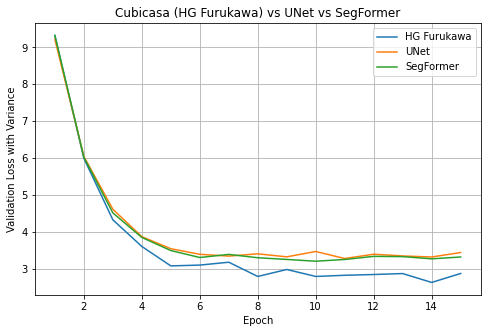

In [21]:
import re
import matplotlib.pyplot as plt

def extract_losses(logfile):
    losses = []

    with open(logfile, "r") as f:
        lines = f.readlines()

    for line in lines:
        if "total loss with variance" in line:
            match = re.search(r"total loss with variance\s+([0-9.]+)", line)
            if match:
                losses.append(float(match.group(1)))

    return losses

# CHANGE THESE PATHS
hg_log = "runs/baseline/2026-05-08-19:29:14/train.log"
unet_log = "runs/unet/2026-05-08-20:30:12/train.log"
segformer_log = "runs/segformer/2026-05-08-21:54:27/train.log"

hg_losses = extract_losses(hg_log)
unet_losses = extract_losses(unet_log)
segformer_losses = extract_losses(segformer_log)

plt.figure(figsize=(8,5))

plt.plot(range(1, len(hg_losses)+1), hg_losses, label="HG Furukawa")
plt.plot(range(1, len(unet_losses)+1), unet_losses, label="UNet")
plt.plot(range(1, len(segformer_losses)+1), segformer_losses, label="SegFormer")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss with Variance")
plt.title("Cubicasa (HG Furukawa) vs UNet vs SegFormer")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
!find runs -name train.log

runs/baseline/2026-05-08-19:29:14/train.log
runs/baseline_oldexp/2026-05-08-10:47:30/train.log
runs/segformer/2026-05-08-21:54:27/train.log
runs/unet/2026-05-08-20:30:12/train.log
